# UI-TARS 2B

run on [kaggle](https://www.kaggle.com/code/aliaagheis/02-smoke-check-ui-tars-2b) or colab 

In [1]:
!pip install qwen-vl-utils
!git clone https://github.com/bytedance/UI-TARS

%cd UI-TARS
!hf download ByteDance-Seed/UI-TARS-2B-SFT --local-dir ./models/ui-tars-2b

!curl -L -o onenote.png "https://raw.githubusercontent.com/YaraHisham61/Click2Act/exp-models-benchmarks/imgs/onenote.png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 48.2 MB/s eta 0:00:00:00:0100:01
Cloning into 'UI-TARS'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (261/261), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 521 (delta 217), reused 191 (delta 191), pack-reused 260 (from 1)
Receiving objects: 100% (521/521), 43.19 MiB | 38.29 MiB/s, done.
Resolving deltas: 100% (306/306), done.
/kaggle/working/UI-TARS
A new version of huggingface_hub (1.11.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

Fetching 14 files: 100%|████████████████████████| 14/14 [00:47<00:00,  3.41s/it]
Download complete: : 9.79GB [00:47, 169MB/s]              /kaggle/working/UI-TARS/models/ui-tars-2b
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  118k  100  118k    0     0   593k      0 --:--:-- --:--:-- -

In [2]:
%cd UI-TARS

[Errno 2] No such file or directory: 'UI-TARS'
/kaggle/working/UI-TARS


In [3]:
import torch
from PIL import Image
import numpy as np
from qwen_vl_utils import process_vision_info
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor

In [4]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import numpy as np

def draw_click(image, x: int, y: int, radius: int = 20, opacity: float = 0.6,
               color: str = None):
    """Overlay a semi-transparent circle on an image to mark a click point.

    Args:
        image   : PIL.Image or numpy array (H, W, 3).
        x, y    : pixel coordinates of the circle centre.
        radius  : circle radius in pixels.
        opacity : alpha in [0, 1] — 0 = invisible, 1 = fully opaque.
        color   : hex colour string (default: C2A_PALETTE["warning"]).
        figsize : matplotlib figure size (used only when ax is None).
        ax      : existing Axes to draw on, or None for a standalone figure.
    """
    if color is None:
        color = C2A_PALETTE["warning"]

    # --- normalise to PIL RGB ---
    if isinstance(image, np.ndarray):
        pil_img = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    else:
        pil_img = image.convert("RGB")

    # --- parse hex colour to RGB tuple ---
    hex_color = color.lstrip("#")
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    # --- draw circle on a transparent overlay ---
    overlay = Image.new("RGBA", pil_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    alpha = int(opacity * 255)
    bbox = [x - radius, y - radius, x + radius, y + radius]
    draw.ellipse(bbox, fill=(*rgb, alpha), outline=(*rgb, 255), width=2)

    # --- composite onto the original ---
    result = Image.alpha_composite(pil_img.convert("RGBA"), overlay).convert("RGB")
    

    return result


In [5]:
model_path = './models/ui-tars-2b'
device = 'cuda'
C2A_PALETTE = {
    "primary"   : "#2E86AB",
    "secondary" : "#A23B72",
    "tertiary"  : "#F18F01",
    "neutral"   : "#6C757D",
    "success"   : "#3BB273",
    "warning"   : "#E84855",
    "bg"        : "#F8F9FA",
    "text"      : "#212529",
}
temperature: float = 0
max_new_tokens: int = 1024

In [6]:
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# !!! THE ORIGINAL GROUNDING PROMPT NOT WORKING
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! 
# Copyright (c) 2025 Bytedance Ltd. and/or its affiliates
# SPDX-License-Identifier: Apache-2.0
COMPUTER_USE_DOUBAO = """You are a GUI agent. You are given a task and your action history, with screenshots. You need to perform the next action to complete the task.

## Output Format
```
Thought: ...
Action: ...
```

## Action Space

click(point='<point>x1 y1</point>')
left_double(point='<point>x1 y1</point>')
right_single(point='<point>x1 y1</point>')
drag(start_point='<point>x1 y1</point>', end_point='<point>x2 y2</point>')
hotkey(key='ctrl c') # Split keys with a space and use lowercase. Also, do not use more than 3 keys in one hotkey action.
type(content='xxx') # Use escape characters \\', \\\", and \\n in content part to ensure we can parse the content in normal python string format. If you want to submit your input, use \\n at the end of content. 
scroll(point='<point>x1 y1</point>', direction='down or up or right or left') # Show more information on the `direction` side.
wait() #Sleep for 5s and take a screenshot to check for any changes.
finished(content='xxx') # Use escape characters \\', \\", and \\n in content part to ensure we can parse the content in normal python string format.


## Note
- Use {language} in `Thought` part.
- Write a small plan and finally summarize your next action (with its target element) in one sentence in `Thought` part.

## User Instruction
{instruction}
"""

MOBILE_USE_DOUBAO = """You are a GUI agent. You are given a task and your action history, with screenshots. You need to perform the next action to complete the task. 
## Output Format
```
Thought: ...
Action: ...
```
## Action Space

click(point='<point>x1 y1</point>')
long_press(point='<point>x1 y1</point>')
type(content='') #If you want to submit your input, use "\\n" at the end of `content`.
scroll(point='<point>x1 y1</point>', direction='down or up or right or left')
open_app(app_name=\'\')
drag(start_point='<point>x1 y1</point>', end_point='<point>x2 y2</point>')
press_home()
press_back()
finished(content='xxx') # Use escape characters \\', \\", and \\n in content part to ensure we can parse the content in normal python string format.


## Note
- Use {language} in `Thought` part.
- Write a small plan and finally summarize your next action (with its target element) in one sentence in `Thought` part.

## User Instruction
{instruction}
"""

GROUNDING_DOUBAO = """You are a GUI agent. You are given a task and your action history, with screenshots. You need to perform the next action to complete the task. \n\n## Output Format\n\nAction: ...\n\n\n## Action Space\nclick(point='<point>x1 y1</point>'')\n\n## User Instruction
{instruction}"""

In [7]:
IMAGE_FACTOR = 28
MIN_PIXELS = 100 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28
MAX_RATIO = 200


def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor


def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor


def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor
    
def smart_resize(height: int,
                 width: int,
                 factor: int = IMAGE_FACTOR,
                 min_pixels: int = MIN_PIXELS,
                 max_pixels: int = MAX_PIXELS) -> tuple[int, int]:
    """
    Rescales the image so that the following conditions are met:

    1. Both dimensions (height and width) are divisible by 'factor'.

    2. The total number of pixels is within the range ['min_pixels', 'max_pixels'].

    3. The aspect ratio of the image is maintained as closely as possible.
    """
    if max(height, width) / min(height, width) > MAX_RATIO:
        raise ValueError(
            f"absolute aspect ratio must be smaller than {MAX_RATIO}, got {max(height, width) / min(height, width)}"
        )
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = floor_by_factor(height / beta, factor)
        w_bar = floor_by_factor(width / beta, factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = ceil_by_factor(height * beta, factor)
        w_bar = ceil_by_factor(width * beta, factor)
    return h_bar, w_bar

In [8]:
image_path = 'onenote.png'
image = Image.open(image_path)
image_rgb = image.convert('RGB')
image_np = np.array(image_rgb)
w, h = image_rgb.size
print('image size:', w, h)

image size: 1919 1079


In [9]:
new_h, new_w = smart_resize(h, w)

new_h, h, new_w, w

(1092, 1079, 1932, 1919)

In [10]:
# ??image.resize

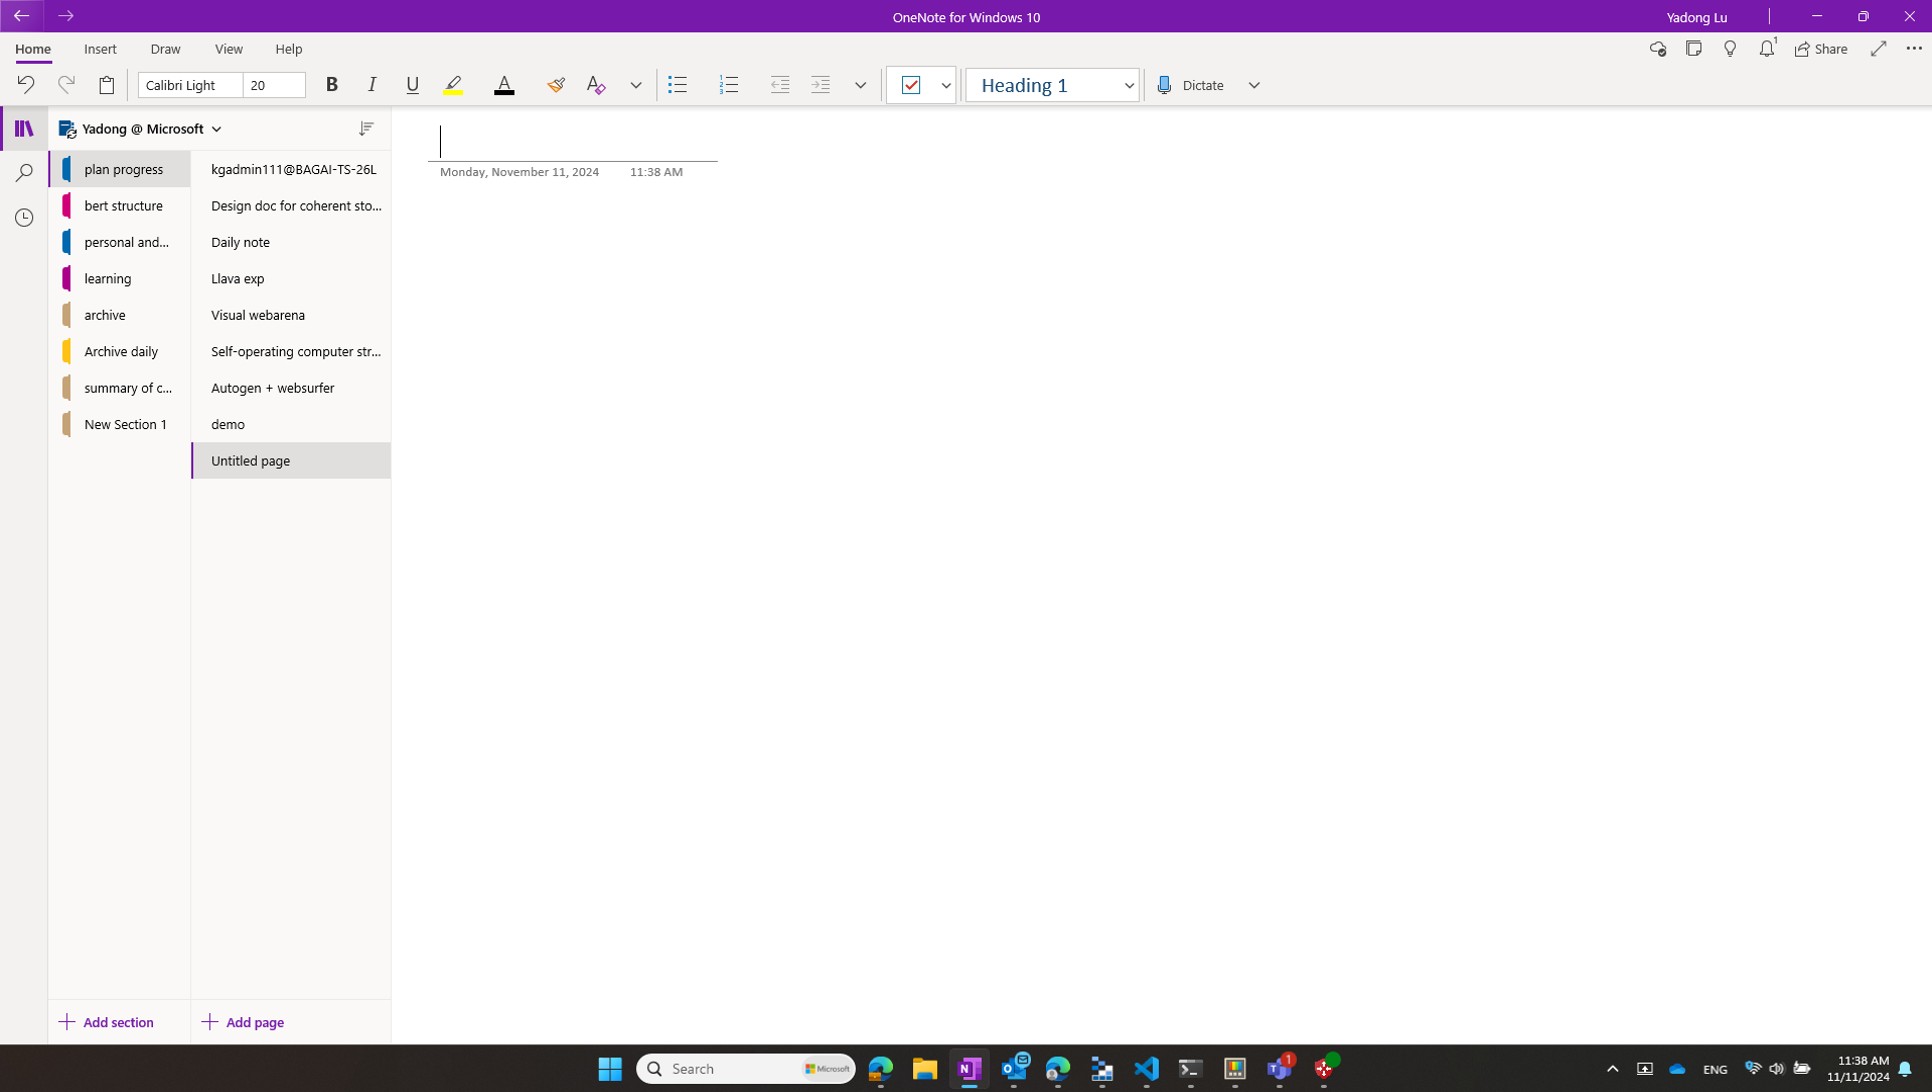

In [11]:
image.resize((new_w, new_h))

In [16]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.float16,      # Use fp16 to halve memory usage
    device_map="auto"               # Automatically splits across both T4s
)

processor = Qwen2VLProcessor.from_pretrained(model_path)
tokenizer = processor.tokenizer

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [38]:
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text":  "## User Instructions:\n add new page",
            # "text": GROUNDING_DOUBAO.format(instruction=task) # >>> NOT WORKING
        }
    ],
}]

In [39]:
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


In [40]:
# Trim the prompt from the output
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

output_text[0]

'(135,934)'

In [42]:
x_model = 135
y_model = 934

## Failed Ways To generate x,y

> https://github.com/bytedance/UI-TARS/blob/main/README_coordinates.md not working

In [43]:
new_height, new_width = smart_resize(h, w)
new_coordinate = (int(x_model/new_width * w), int(y_model/new_height * h))
print(f'Resized resolution: {new_width}, {new_height}')
print(new_coordinate)

Resized resolution: 1932, 1092
(134, 922)


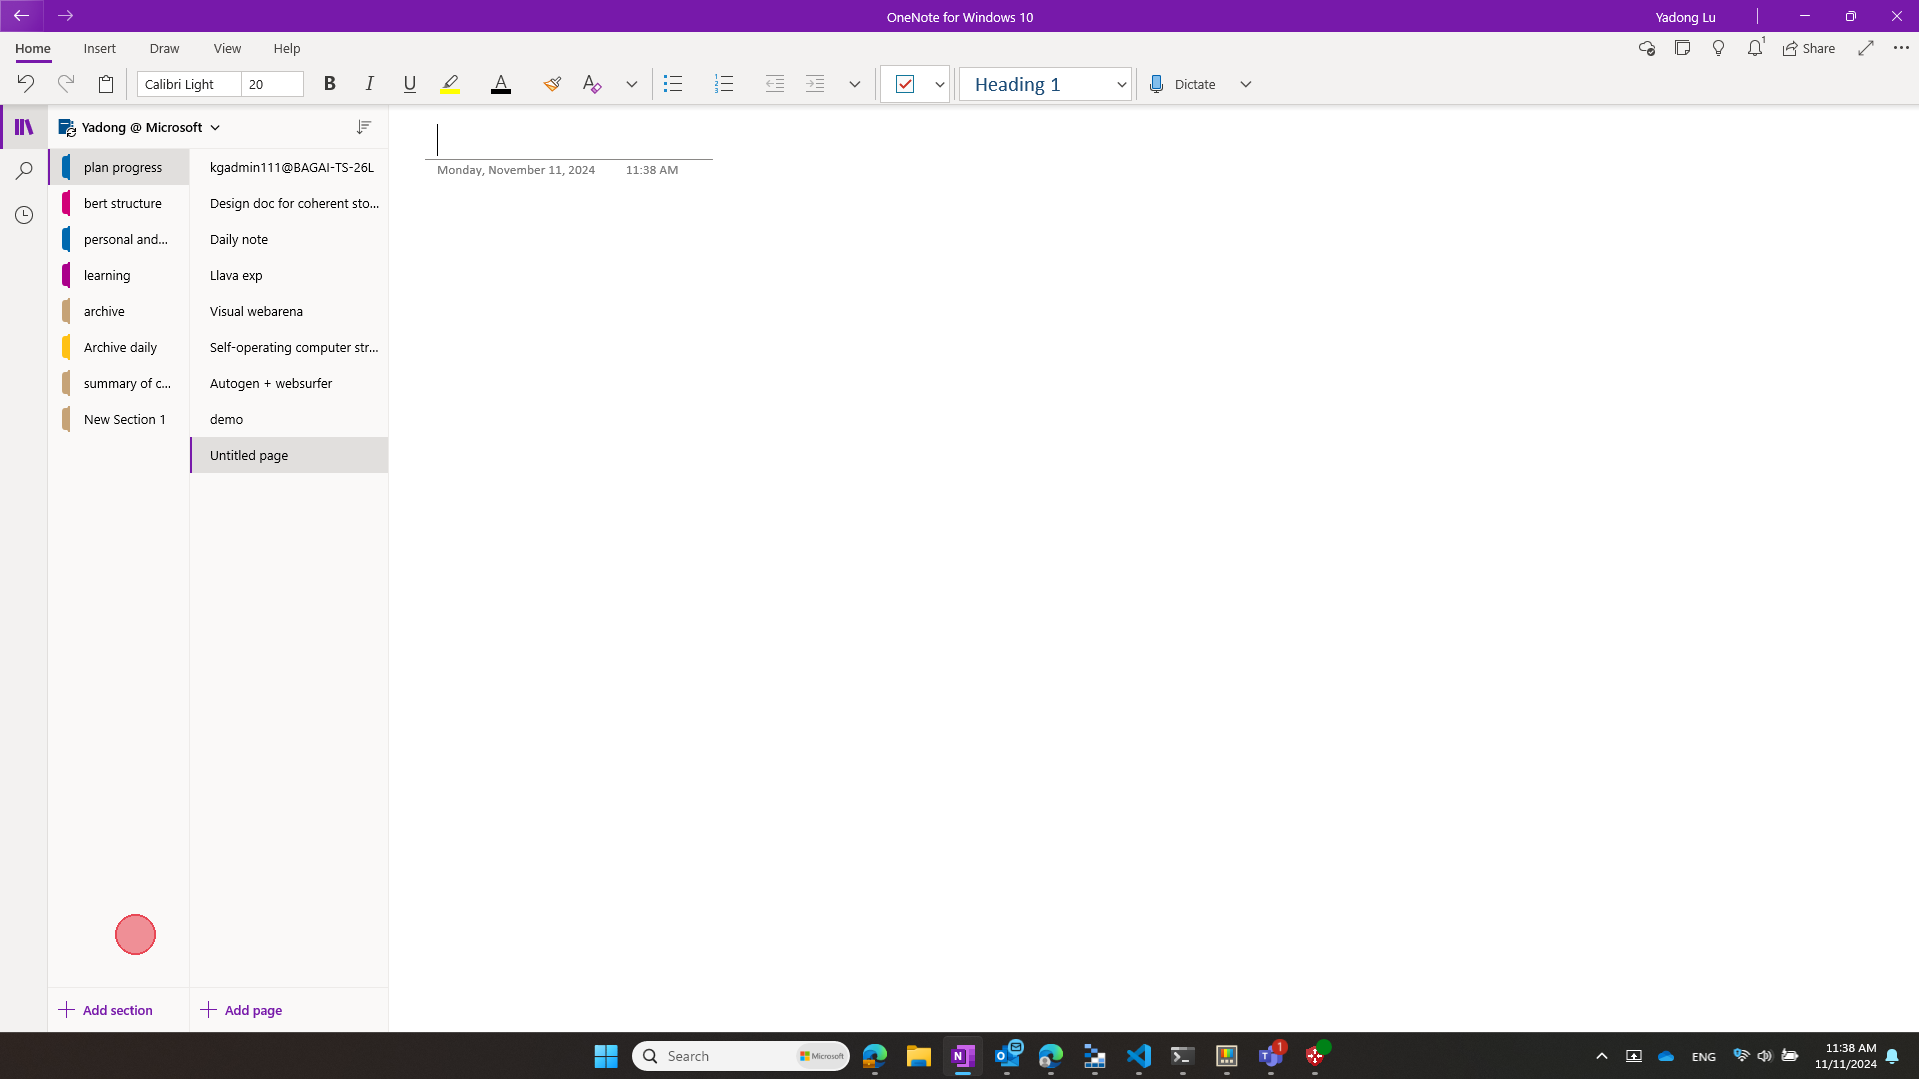

In [44]:
draw_click(image_rgb, x_model, y_model)

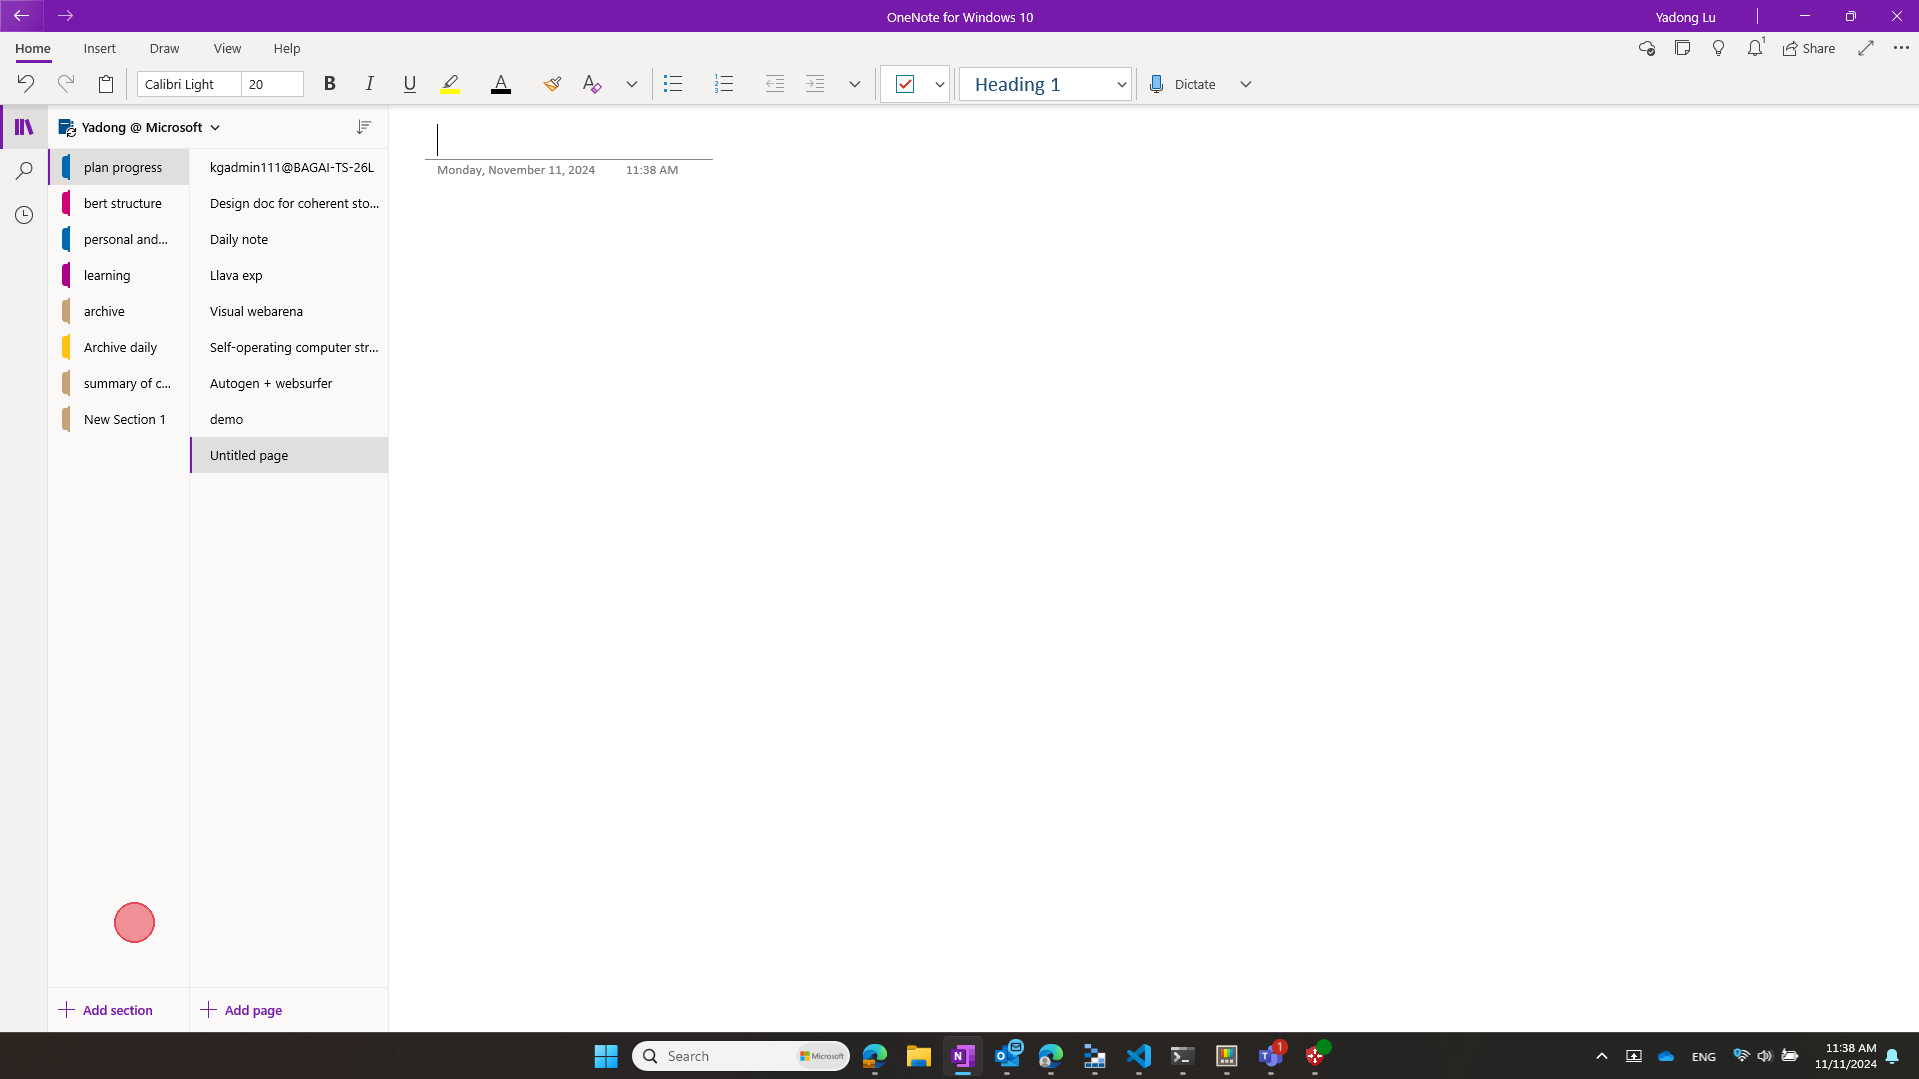

In [45]:
draw_click(image_rgb, new_coordinate[0], new_coordinate[1])


## Success Way To generate x,y

In [46]:
# gemini Method
new_coordinate = (int(x_model/1000 * w), int(y_model/1000 * h))
print(new_coordinate)

(259, 1007)


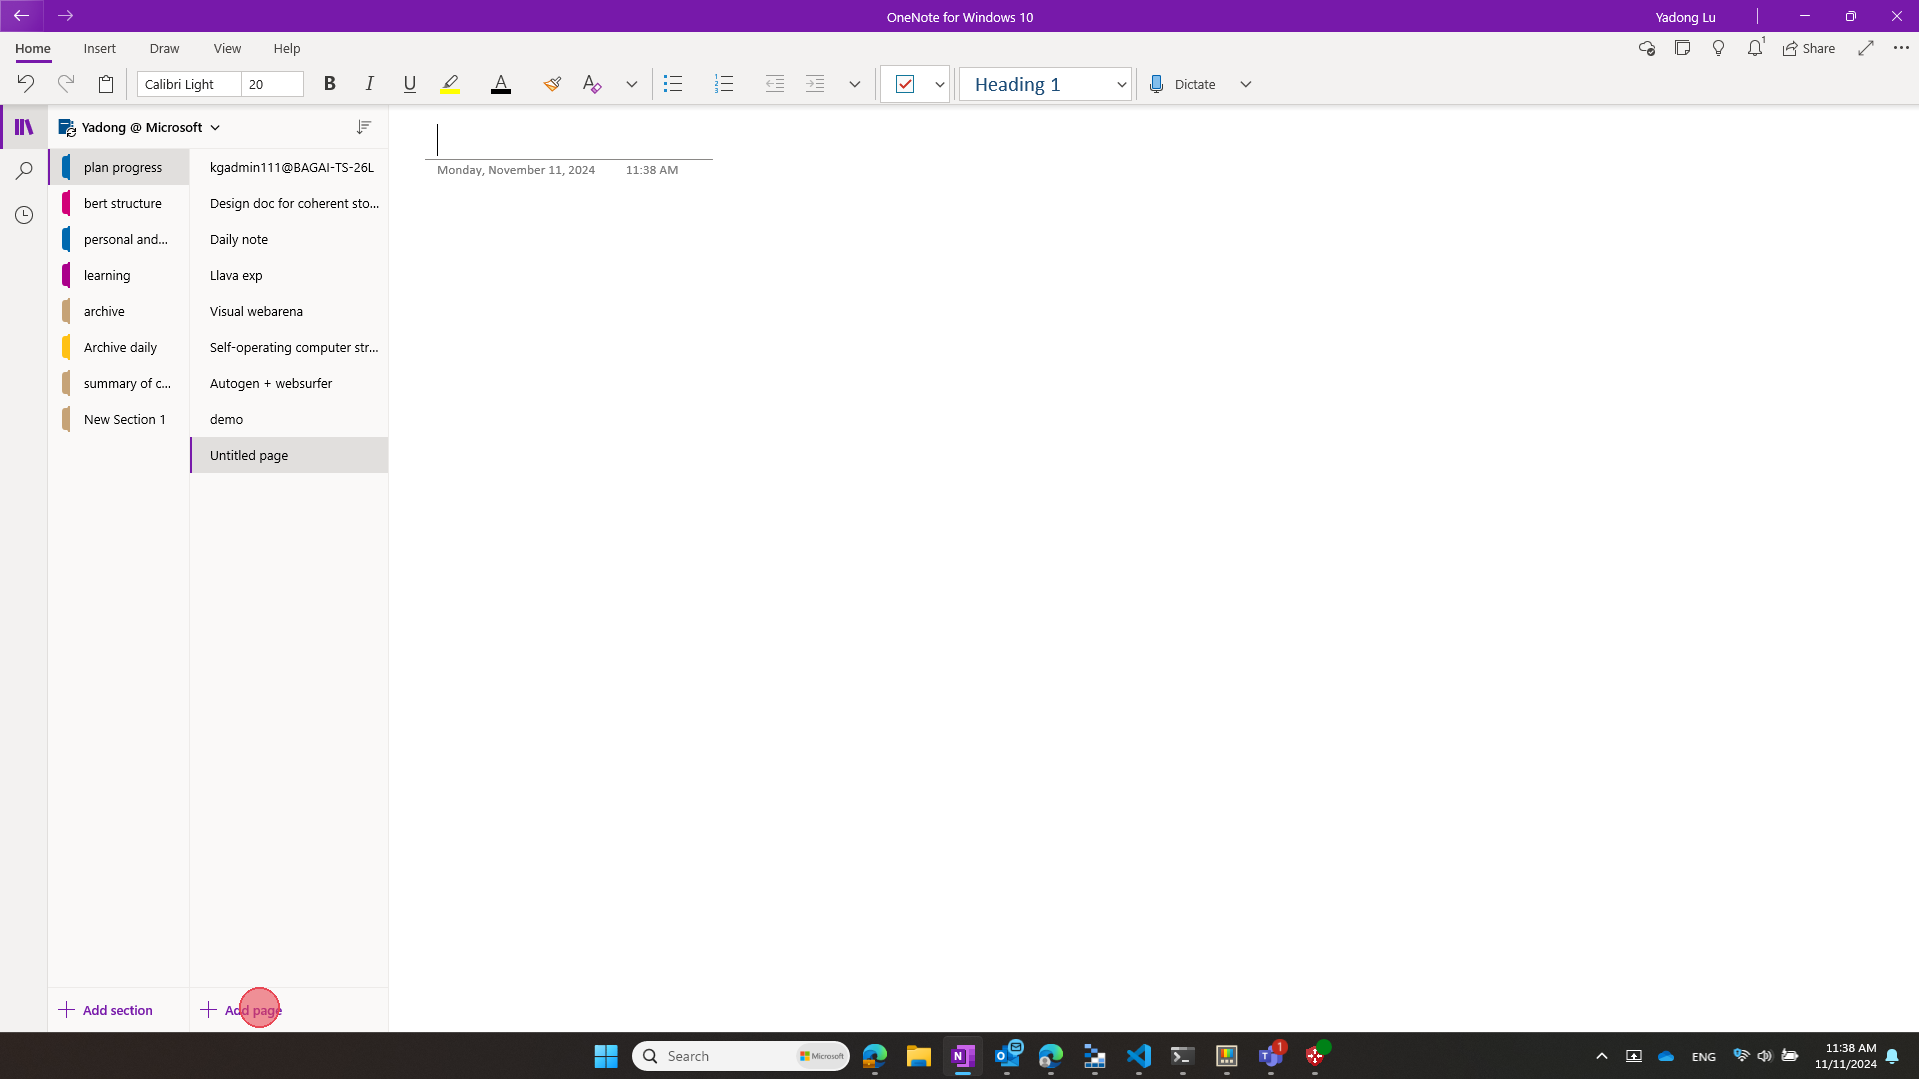

In [47]:
draw_click(image_rgb, 259, 1007)

# Example 2

In [54]:
task = "change font size to 32"
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text":  f"## User Instructions:\n {task}", 
        }
    ],
}]
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
# Trim the prompt from the output
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

output_text[0]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


'(130,76)'

new coordinates:  (249, 82)


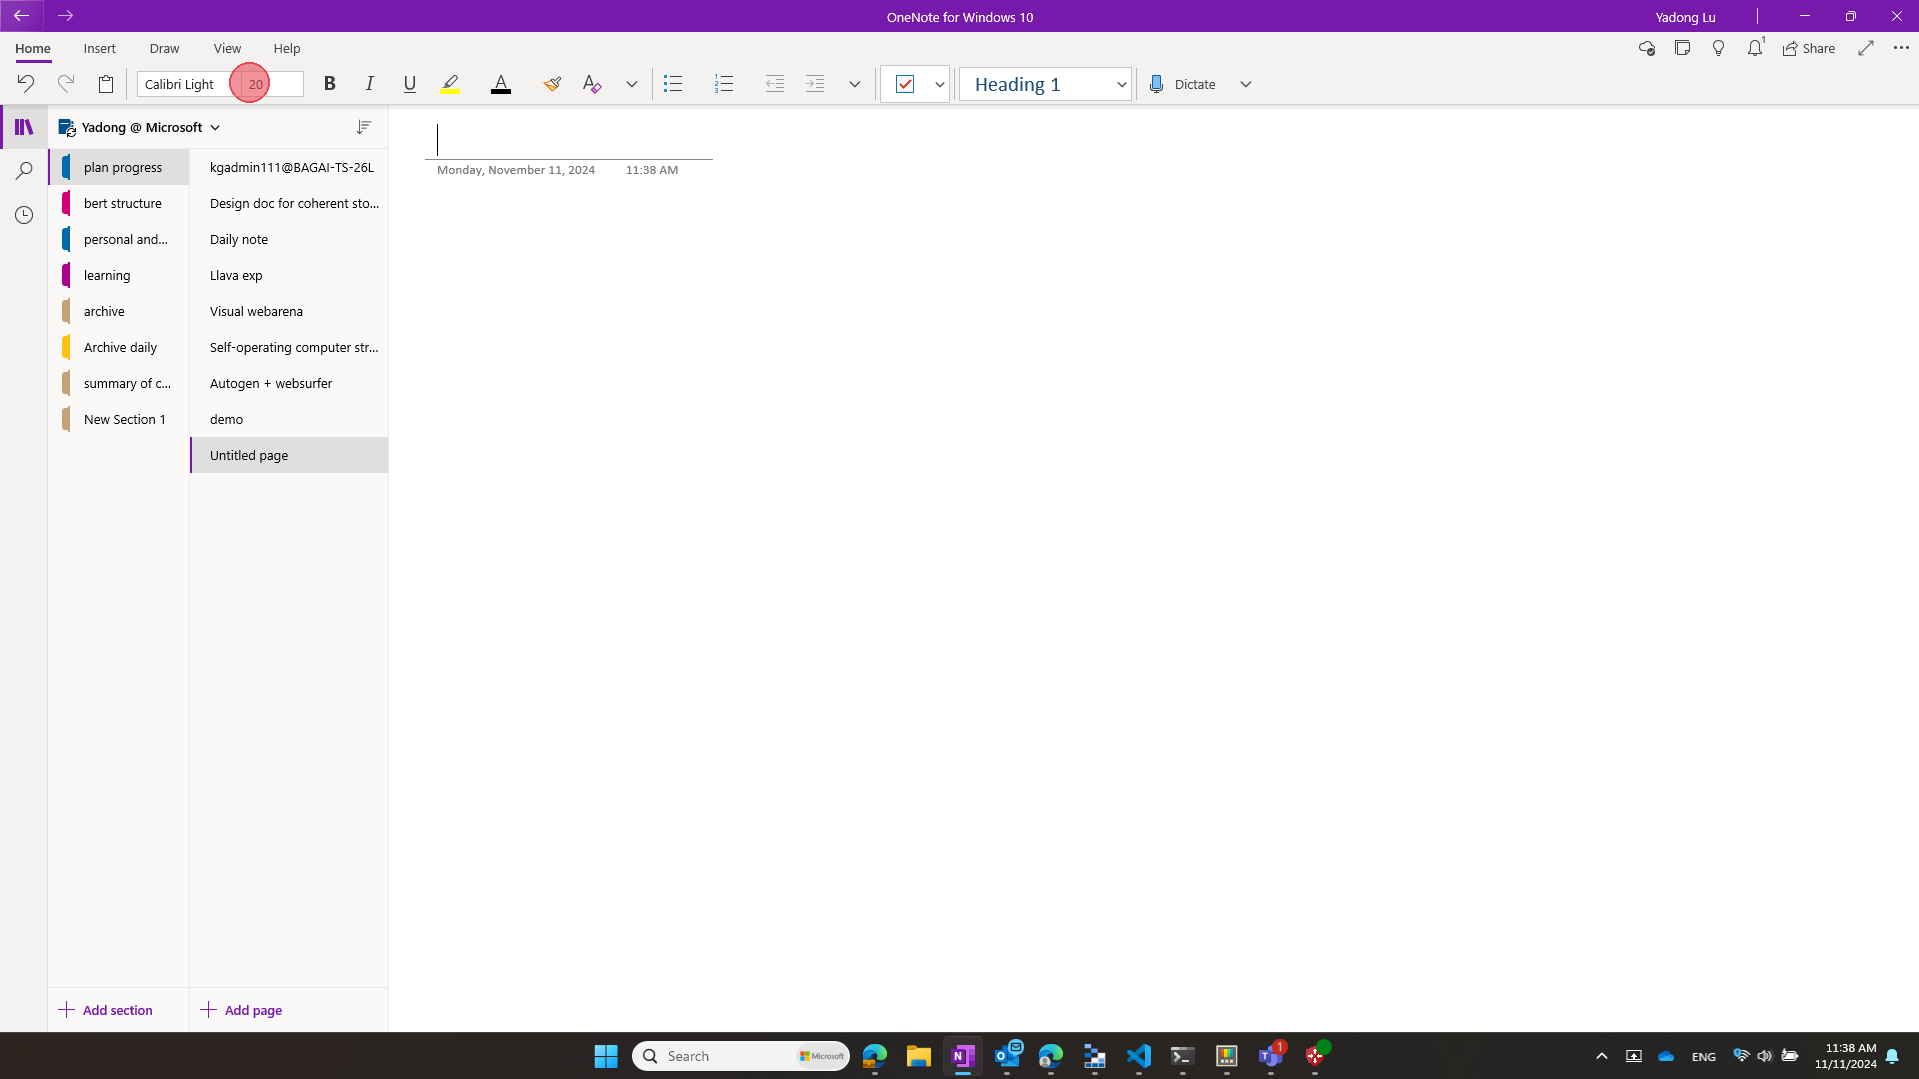

In [56]:
# gemini Method
new_coordinate = (int(130/1000 * w), int(76/1000 * h))
print("new coordinates: ", new_coordinate)
draw_click(image_rgb, new_coordinate[0], new_coordinate[1])


### Sample 2 - Try add System Prompt

**FAILED**

In [57]:
task = "change font size to 32"
messages = [
    {
        "role": "system",
        "content": """You are a GUI agent. You are given a task and your action history, with screenshots. You need to perform the next action to complete the task. \n\n## Output Format\n\nAction: ...\n\n\n## Action Space\nclick(point='<point>x1 y1</point>'')"""
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_rgb},
            {
                "type": "text",
                "text":  f"## User Instructions:\n {task}", 
            }
        ],
    }
]
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
# Trim the prompt from the output
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

output_text[0]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


"Action: click(start_box='(118,81)')"

new coordinates:  (226, 87)


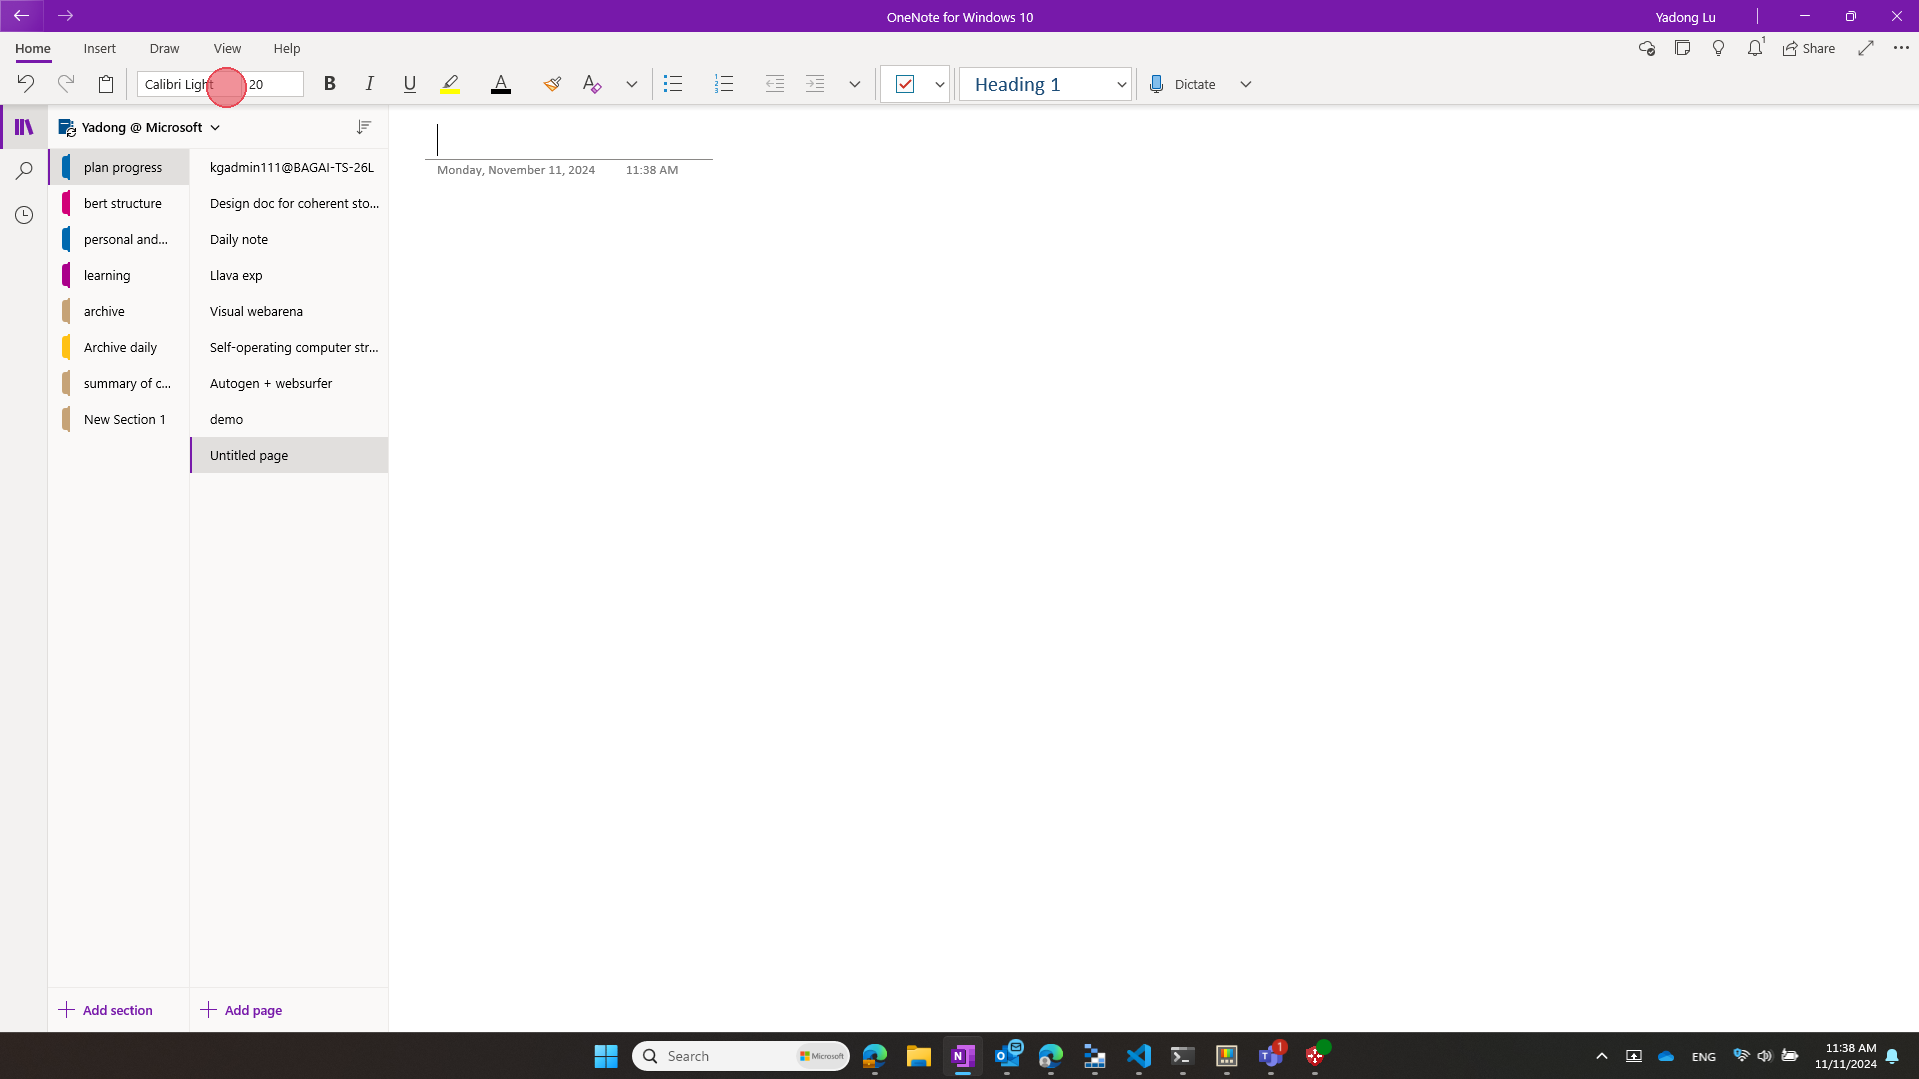

In [60]:
# gemini Method
new_coordinate = (int(118/1000 * w), int(81/1000 * h))
print("new coordinates: ", new_coordinate)
draw_click(image_rgb, new_coordinate[0], new_coordinate[1])


# Example 3

In [61]:
task = "save notebook to the cloud"
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text":  f"## User Instructions:\n {task}", 
        }
    ],
}]
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
# Trim the prompt from the output
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

output_text[0]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


'To save the notebook to the cloud, I would need to use the cloud storage feature in OneNote. This feature is typically accessed through the cloud icon in the top-right corner of the interface. I would click on this icon to open the cloud storage options and select the desired cloud service for saving the notebook.'

In [63]:
task = "save notebook to the cloud"
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text":  f"## Instructions generate (x,y) coordinates to where I should click ## User Instructions:\n {task}", 
        }
    ],
}]
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
# Trim the prompt from the output
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

output_text[0]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


'(862,43)'

new coordinates:  (1654, 46)


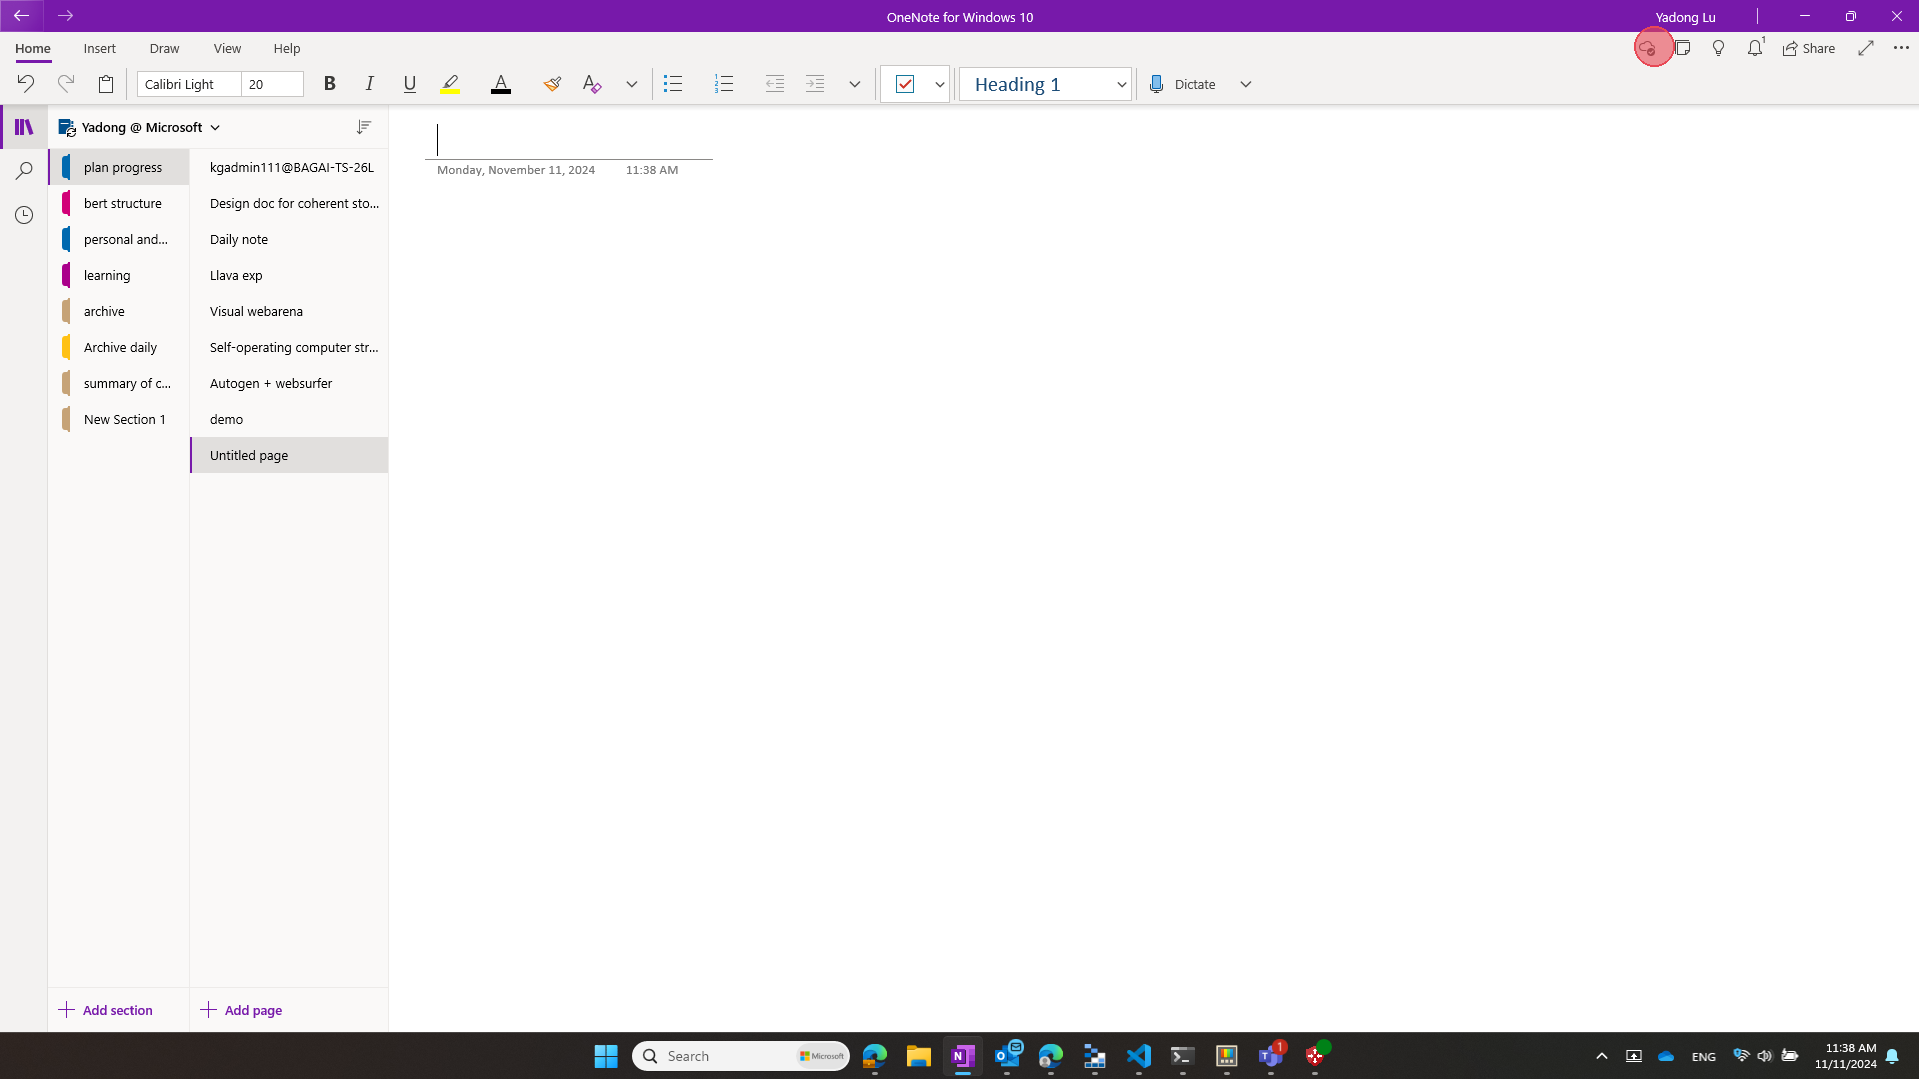

In [64]:
# gemini Method
new_coordinate = (int(862/1000 * w), int(43/1000 * h))
print("new coordinates: ", new_coordinate)
draw_click(image_rgb, new_coordinate[0], new_coordinate[1])


| **The First one to solve this**

# Sample 5

In [65]:
task = "select text highlighter"
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text":  f"## Instructions generate (x,y) coordinates to where I should click ## User Instructions:\n {task}", 
        }
    ],
}]
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
#  Apply chat template (converts to a single string with special tokens)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
# Extract image tensors from the messages structure
image_inputs, video_inputs = process_vision_info(messages)
# Tokenize everything together
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
# generate output
inputs = inputs.to(model.device)
generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
# Trim the prompt from the output
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
# decode
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)

output_text[0]

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


'(233,75)'

new coordinates:  (447, 80)


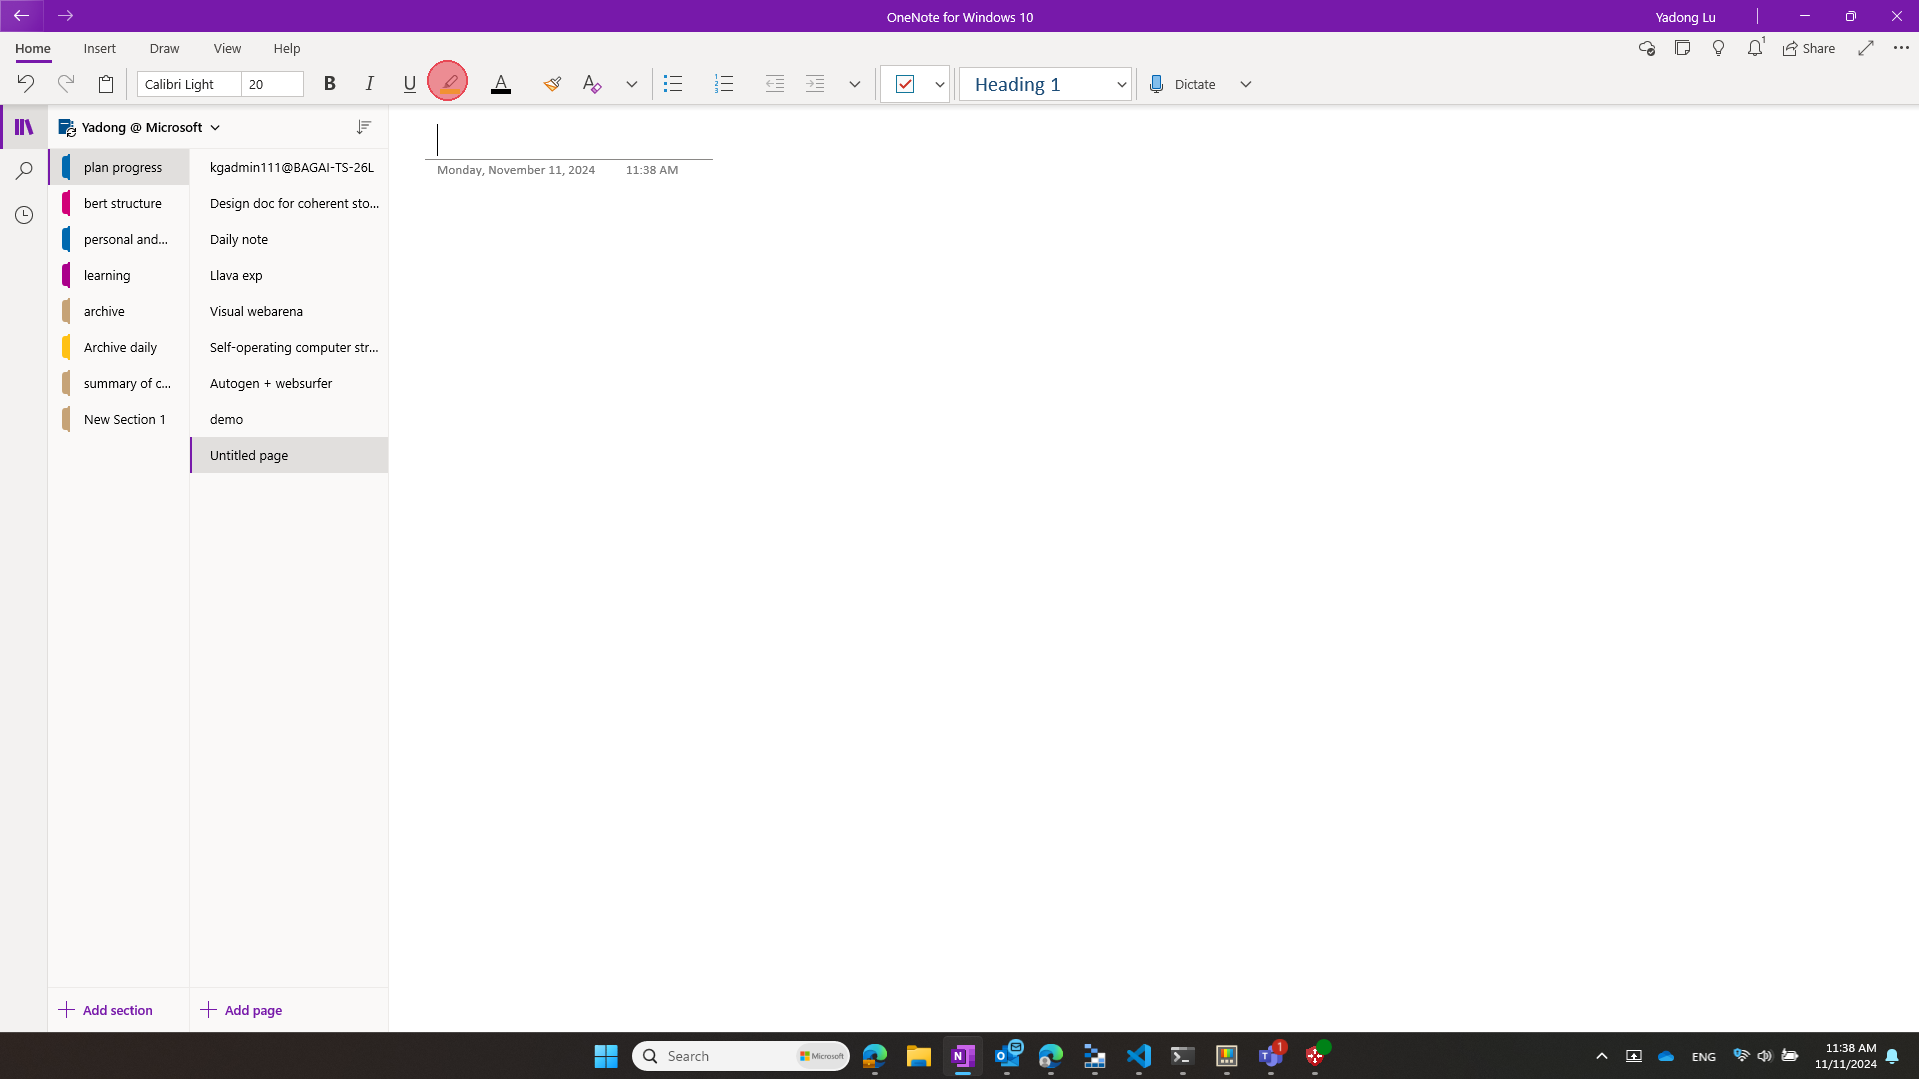

In [66]:
# gemini Method
new_coordinate = (int(233/1000 * w), int(75/1000 * h))
print("new coordinates: ", new_coordinate)
draw_click(image_rgb, new_coordinate[0], new_coordinate[1])